<a href="https://colab.research.google.com/github/JourdynLuv/JourdynLuv/blob/main/Razai_Khalid_4_5_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


For this analysis, I am using the `mpg` dataset provided by the Seaborn library. This is a classic machine learning dataset containing technical specifications of various automobiles.

* `mpg`: Miles per gallon (Continuous) - This is the target variable we are trying to understand and predict.

* `cylinders`: Number of cylinders in the engine (Discrete)
* `displacement`: Engine displacement in cubic inches (Continuous)
* `horsepower`: Engine horsepower (Continuous)
* `weight`: Vehicle weight in lbs (Continuous)
* `acceleration`: Time to accelerate from 0 to 60 mph in seconds (Continuous)
* `model_year`: Year the car model was released (Discrete)
* `origin`: Region of origin (Categorical: usa, europe, japan)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('mpg')

df = df.dropna()

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


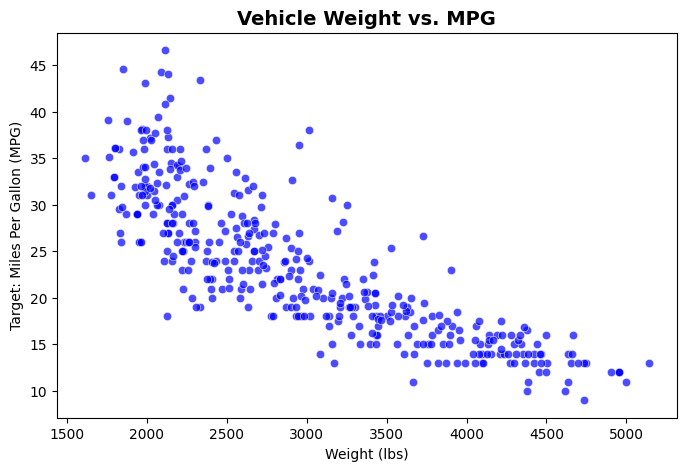

In [2]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='weight', y='mpg', alpha=0.7, color='blue')
plt.title('Vehicle Weight vs. MPG', fontsize=14, fontweight='bold')
plt.xlabel('Weight (lbs)')
plt.ylabel('Target: Miles Per Gallon (MPG)')
plt.show()

This scatter plot compares the feature of interest weight against the target feature mpg. There is a very strong, non-linear negative correlation between weight and fuel efficiency. As vehicle weight increases, the miles per gallon predictably drop, making weight a highly important predictor for any future ML model.

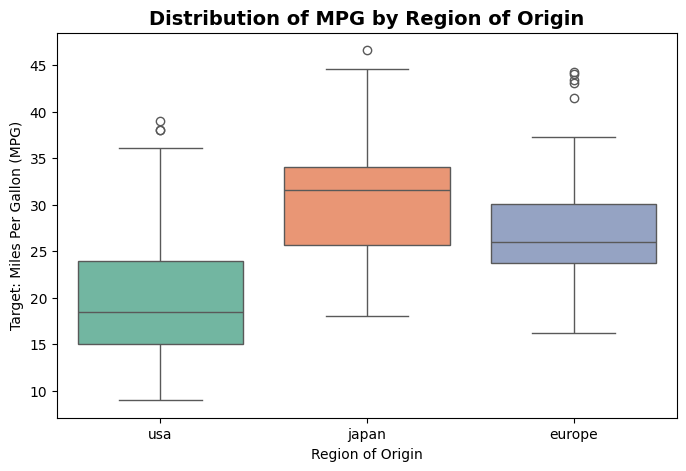

In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='origin', y='mpg', palette='Set2', hue='origin', legend=False)
plt.title('Distribution of MPG by Region of Origin', fontsize=14, fontweight='bold')
plt.xlabel('Region of Origin')
plt.ylabel('Target: Miles Per Gallon (MPG)')
plt.show()

This box plot examines the relationship between a categorical feature origin and the target feature mpg. Vehicles originating from Japan have the highest median MPG and the widest distribution of high-efficiency outliers. In contrast, USA-made vehicles have a tightly clustered, significantly lower median MPG, proving that region of origin is a strong classifying feature.

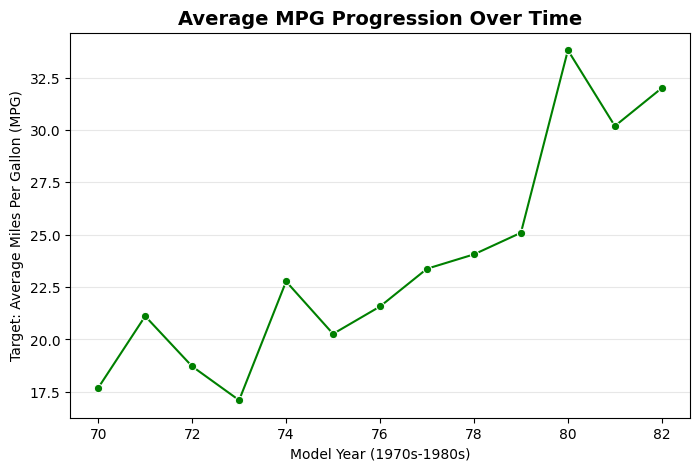

In [4]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='model_year', y='mpg', marker='o', color='green', errorbar=None)
plt.title('Average MPG Progression Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Model Year (1970s-1980s)')
plt.ylabel('Target: Average Miles Per Gallon (MPG)')
plt.grid(axis='y', alpha=0.3)
plt.show()

This line chart tracks the feature of interest model year against the average of the target feature mpg. There is a clear upward, positive trend indicating that as the model year increases, the fuel efficiency generally improves. This shows that time is a reliable predictor for an increase in the target variable.

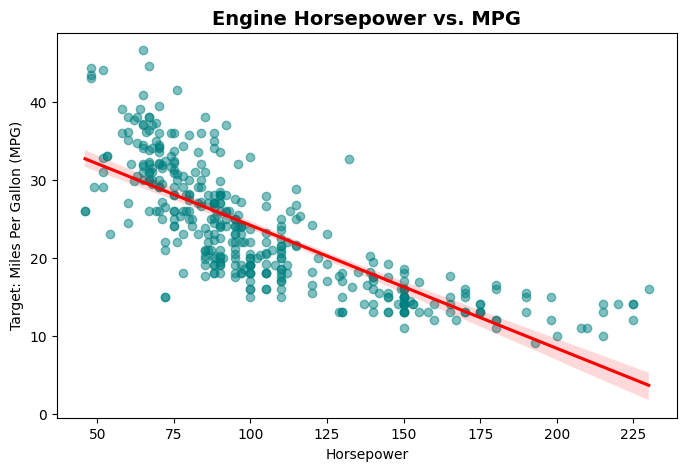

In [5]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='horsepower', y='mpg', scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Engine Horsepower vs. MPG', fontsize=14, fontweight='bold')
plt.xlabel('Horsepower')
plt.ylabel('Target: Miles Per Gallon (MPG)')
plt.show()

This regression plot shows the relationship between horsepower and the target feature mpg. Similar to weight, horsepower has a strong negative correlation with fuel efficiency. The red trend line clearly demonstrates that as engine power increases, the miles per gallon steadily and predictably decrease.

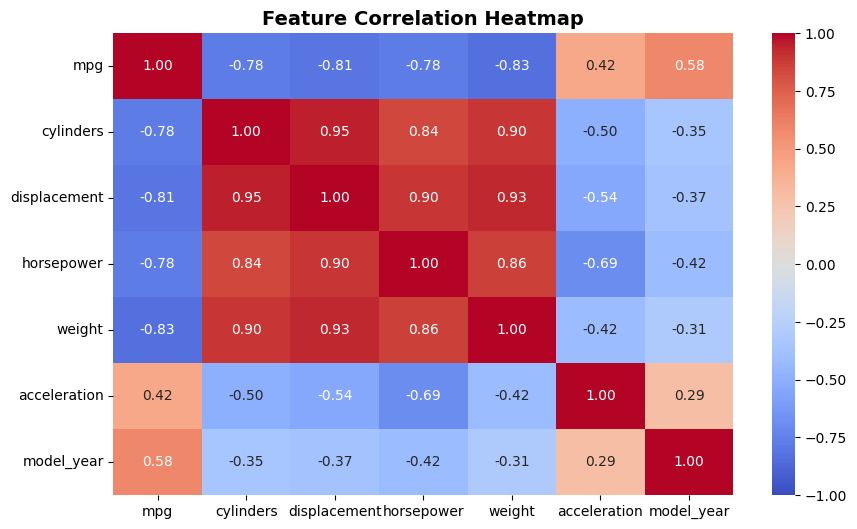

In [6]:
plt.figure(figsize=(10, 6))

numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

This heatmap displays the mathematical correlation between all numeric features and the target feature mpg. We can instantly identify which features are most and least related to the target. weight and displacement have the strongest negative correlation to mpg, making them the most critical predictive features. Conversely, acceleration  has the weakest correlation to the target feature.


Based on the Exploratory Data Analysis , the mpg target feature is highly dependent on the physical mass and engine size of the vehicle. If we were to train a Machine Learning regression model to predict fuel efficiency, weight, displacement, and cylinders would act as the primary negative predictors, while model_year and origin would act as the primary positive predictors. The data confirms that over the 12-year span recorded, engineering shifted away from heavy, low-efficiency models toward lighter, more efficient designs.